## Análisis de Riesgo Crediticio con Machine Learning
En este cuaderno vamos a construir un modelo de Machine Learning para predecir si un cliente tiene probabilidad de caer en mora con su préstamo o no. Usaremos un dataset llamado `prestacar.csv`. 

El reto principal aquí es que, afortunadamente, la mayoría de las personas pagan sus deudas, por lo que tenemos pocas personas morosas en comparación con las cumplidas. A esto se le llama tener "clases desbalanceadas", y a lo largo de este proyecto iremos viendo cómo manejarlo para que nuestro modelo realmente aprenda a detectar a los morosos.

In [46]:
import pandas as pd

In [47]:
data = pd.read_csv('prestacar.csv')

In [48]:
data.head()

,ingresos_cliente,anualidad_prestamo,años_casa_propia,telefono_trab,evaluacion_ciudad,score_1,score_2,score_3,score_social,cambio_telefono,moroso
0,12600.0,3569.400000,12.157324,1,2.0,0.057153,0.527227,0.513171,0.117428,2545.0,0
1,9000.0,2722.188351,7.000000,0,2.0,0.657661,0.285898,0.614414,0.222700,495.0,0
2,15750.0,4477.500000,12.000000,0,2.0,0.501213,0.695423,0.513171,0.117428,1212.0,0
3,9000.0,1309.050000,12.157324,0,3.0,0.501213,0.155973,0.513171,0.117428,515.0,0
4,7650.0,1125.000000,12.157324,0,2.0,0.294328,0.152076,0.513171,0.117428,162.0,0


### Preparación de los Datos

Antes de cualquier modelo, necesitamos separar nuestra información. Guardaremos en `X` todas las características del cliente (ingresos, años en casa propia, etc.) y en `y` lo que queremos predecir, que es la columna `moroso`.

In [49]:
X = data.drop(columns='moroso', axis=1)
y = data['moroso']

### Entrenamiento del Modelo Inicial

Para arrancar, probamos con un Árbol de Decisión básico. Le pasamos todos nuestros datos directamente (`X` e `y`). Este será nuestro punto de partida o *baseline*.

In [50]:
from sklearn.tree import DecisionTreeClassifier

modelo= DecisionTreeClassifier()

modelo.fit(X, y)

DecisionTreeClassifier()

In [51]:
print(f'la exactitud del modeloo fue: {modelo.score(X, y)}')

la exactitud del modeloo fue: 1.0


### División en Entrenamiento, Validación y Prueba

Si evaluamos el modelo con los mismos datos que usó para aprender, nos dará una puntuación perfecta (como vimos arriba, exactitud de 1.0), pero eso es trampa porque se "memorizó" las respuestas. 

Para saber si de verdad está aprendiendo, vamos a dividir nuestros datos en tres partes:
1. **Entrenamiento (`X_train`)**: Para que el modelo aprenda.
2. **Validación (`X_val`)**: Para ir afinando el modelo y ver cómo se comporta.
3. **Prueba (`X_test`)**: Un conjunto que guardaremos bajo llave hasta el final para la prueba de fuego.

In [52]:
from sklearn.model_selection import train_test_split


X, X_test, y, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=5) 
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, random_state=5) 

In [53]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [54]:
print(f'la exactitud del modeloo en entrenamiento fue: {modelo.score(X_train, y_train)}')
print(f'la exactitud del modeloo en validación fue: {modelo.score(X_val, y_val)}')

la exactitud del modeloo en entrenamiento fue: 0.9205574912891986
la exactitud del modeloo en validación fue: 0.9058444386377493


### Evaluación Visual: La Matriz de Confusión

La exactitud a veces engaña. Si el 90% de los clientes paga y mi modelo siempre dice "todos pagan", tendrá un 90% de exactitud, pero será inútil para el banco

Mejor veamos la matriz de confusión. Esta cuadrícula nos mostrará exactamente dónde se está equivocando el modelo: cuántos morosos detectó realmente y a cuántos dejó pasar por error.

In [55]:
from sklearn.metrics import confusion_matrix

y_previsto = modelo.predict(X_val)
matriz_confusion = confusion_matrix(y_val, y_previsto) 
print(matriz_confusion)


[[10357   122]
 [  959    43]]


In [56]:
from sklearn.metrics import ConfusionMatrixDisplay


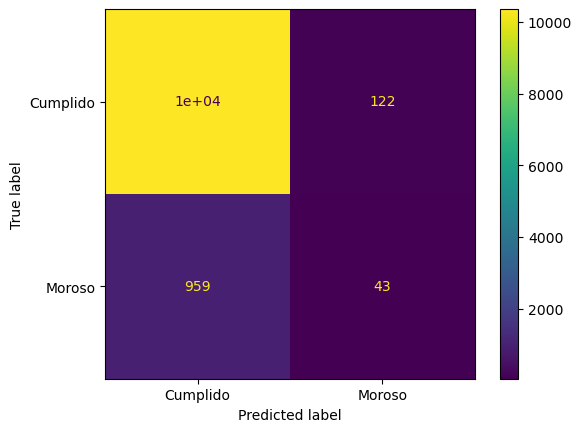

In [57]:
import matplotlib.pyplot as plt
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_confusion, display_labels=['Cumplido', 'Moroso'])
visualizacion.plot()
plt.show()

### Métricas Adicionales más allá de la Exactitud

Para ponerle números a lo que vimos en la gráfica, calculemos métricas clave. Aquí la más importante para nosotros será la **Sensibilidad (Recall)**. El Recall nos dice: "De todos los que *realmente* son morosos, ¿qué porcentaje logró identificar el modelo?". Preferimos equivocarnos y rechazar a alguien bueno (Falso Positivo) que darle un crédito a alguien que no pagará (Falso Negativo).

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print(f'La precisión del modeloo: {precision_score(y_val, y_previsto)}')
print(f'La sensibilidad(Recall) del modeloo: {recall_score(y_val, y_previsto)}')
print(f'La exactitud (accuracy) del modeloo: {accuracy_score(y_val, y_previsto)}')
print(f'F1 del modeloo: {f1_score(y_val, y_previsto)}')


La precisión del modeloo: 0.2606060606060606
La sensibilidad(Recall) del modeloo: 0.04291417165668663
La exactitud (accuracy) del modeloo: 0.9058444386377493
F1 del modeloo: 0.07369323050556983


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_previsto))

              precision    recall  f1-score   support

           0       0.92      0.99      0.95     10479
           1       0.26      0.04      0.07      1002

    accuracy                           0.91     11481
   macro avg       0.59      0.52      0.51     11481
weighted avg       0.86      0.91      0.87     11481



### Validación Cruzada (*Cross-Validation*)

A veces, la forma en que dividimos los datos para entrenar puede hacer que el modelo se vea muy bueno o muy malo por pura casualidad. Para estar más seguros, usaremos Validación Cruzada: dividimos los datos en 5 pedazos, entrenamos el modelo 5 veces usando un pedazo diferente para validar cada vez, y sacamos el promedio de los resultados.

In [60]:
from sklearn.model_selection import KFold, cross_validate


In [62]:
modelo = DecisionTreeClassifier(max_depth=10)

kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, X, y, cv=kf)
cv_resultados

{'fit_time': array([0.37931442, 0.35750556, 0.36084414, 0.36387372, 0.35775304]),
 'score_time': array([0.00573945, 0.00560808, 0.00712299, 0.00480914, 0.00460386]),
 'test_score': array([0.91301034, 0.90722997, 0.90755662, 0.91376307, 0.90015244])}

In [63]:
cv_resultados['test_score']

array([0.91301034, 0.90722997, 0.90755662, 0.91376307, 0.90015244])

In [64]:
promedio = cv_resultados['test_score'].mean()
desvio_std = cv_resultados['test_score'].std()

print(f'El promedio de la exactitud es de {promedio}')
print(f'El desvio tipico es de {desvio_std}')
print(f'El intervalo de confianza es {promedio-2*desvio_std}, {min(promedio+2*desvio_std, 1)}]')

El promedio de la exactitud es de 0.9083424867085595
El desvio tipico es de 0.004901096517472574
El intervalo de confianza es 0.8985402936736144, 0.9181446797435047]


In [65]:
def intervalo_confianza(resultados):
    promedio = resultados['test_score'].mean()
    desvio_std = resultados['test_score'].std()
    print(f'El intervalo de confianza es {promedio-2*desvio_std}, {min(promedio+2*desvio_std, 1)}]')

In [66]:
modelo = DecisionTreeClassifier(max_depth=10)

kf = KFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, X, y, cv=kf, scoring='recall')
cv_resultados

{'fit_time': array([0.37807178, 0.34117293, 0.35535192, 0.40523148, 0.34990239]),
 'score_time': array([0.02978921, 0.00983477, 0.01455736, 0.01180482, 0.01008058]),
 'test_score': array([0.02906209, 0.0210396 , 0.0196802 , 0.01305483, 0.02543353])}

In [68]:
intervalo_confianza(cv_resultados)

El intervalo de confianza es 0.01079555267636664, 0.03251254502259039]


### Análisis del Balance de Clases

Si recordamos el inicio, mencionamos que el problema principal era que los datos estaban desbalanceados. Vamos a comprobar exactamente qué porcentaje de nuestros datos son clientes cumplidos frente a morosos.

In [69]:
data['moroso'].value_counts(normalize=True)

moroso
0    0.912707
1    0.087293
Name: proportion, dtype: float64

In [70]:
from sklearn.model_selection import StratifiedKFold



In [71]:
modelo = DecisionTreeClassifier(max_depth=10)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, X, y, cv=skf, scoring='recall')

In [72]:
intervalo_confianza(cv_resultados)

El intervalo de confianza es 0.02239216221224111, 0.037971908883427954]


### Tratamiento de Datos Desbalanceados: Sobremuestreo (SMOTE)

Como vimos, los morosos son una minoría muy pequeña. Para que el modelo les preste más atención, vamos a usar una técnica llamada SMOTE. Lo que hace es generar clientes morosos "sintéticos" o artificiales (basándose en los reales) hasta que ambas clases estén igualadas. Es como darle más ejemplos al modelo para que pueda aprender mejor sus patrones.

In [73]:
from imblearn.over_sampling import SMOTE


In [74]:
oversampling = SMOTE()
x_balanceada, y_balanceada = oversampling.fit_resample(X, y)

In [75]:
y_balanceada.value_counts()

moroso
0    41912
1    41912
Name: count, dtype: int64

In [76]:
modelo = DecisionTreeClassifier(max_depth=10)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(modelo, x_balanceada, y_balanceada, cv=skf, scoring='recall')

In [77]:
intervalo_confianza(cv_resultados)

El intervalo de confianza es 0.710539621772831, 0.7476099214805172]


### Pipelines y Validación Cruzada Correcta

Hay un detalle crucial al hacer SMOTE: **solo debemos crear datos sintéticos en la parte de entrenamiento**, no en los datos con los que validamos. 

Para asegurarnos de que la Validación Cruzada haga esto bien en cada iteración, creamos un *Pipeline*. Este encapsula el proceso para que primero balancee (SMOTE) y luego entrene, respetando las reglas.

In [78]:
from imblearn.pipeline import Pipeline as imbpipeline



In [79]:
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = imbpipeline([('oversample', SMOTE()), ('arbol', modelo)])

In [80]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados = cross_validate(pipeline, X, y, cv=skf, scoring='recall')

In [82]:
intervalo_confianza(cv_resultados)

El intervalo de confianza es 0.210004786212618, 0.2898765964729901]


### Otra Alternativa: Submuestreo (NearMiss)

En lugar de crear datos falsos para igualar a la mayoría (SMOTE), ¿qué tal si eliminamos datos reales de la mayoría hasta igualar a la minoría? Eso es exactamente lo que hace NearMiss (Under-sampling). 

Vamos a probarlo también en un Pipeline para ver si nos da resultados mejores identificando a los morosos.

In [83]:
from imblearn.under_sampling import NearMiss


In [84]:
modelo = DecisionTreeClassifier(max_depth=10)
pipeline = imbpipeline([('undersample', NearMiss(version=3)), ('arbol', modelo)])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
cv_resultados_3 = cross_validate(pipeline, X, y, cv=skf, scoring='recall')

In [85]:
intervalo_confianza(cv_resultados_3)

El intervalo de confianza es 0.6187890777121279, 0.702719261303006]


In [86]:
undersample = NearMiss(version=3)
x_balanceada ,  y_balanceada = undersample.fit_resample(X, y)

In [87]:
y_balanceada.value_counts()

moroso
0    4009
1    4009
Name: count, dtype: int64

### Evaluación Final del Modelo

Llegó la hora de la verdad. Ya probamos técnicas y vimos que NearMiss o SMOTE nos ayudan a mejorar el Recall. Ahora vamos a entrenar nuestro modelo con los datos balanceados y lo pondremos a prueba definitiva con `X_test`, conjunto que separamos al inicio y que el modelo **nunca ha visto**.

              precision    recall  f1-score   support

           0       0.94      0.48      0.64      7397
           1       0.11      0.70      0.20       707

    accuracy                           0.50      8104
   macro avg       0.53      0.59      0.42      8104
weighted avg       0.87      0.50      0.60      8104



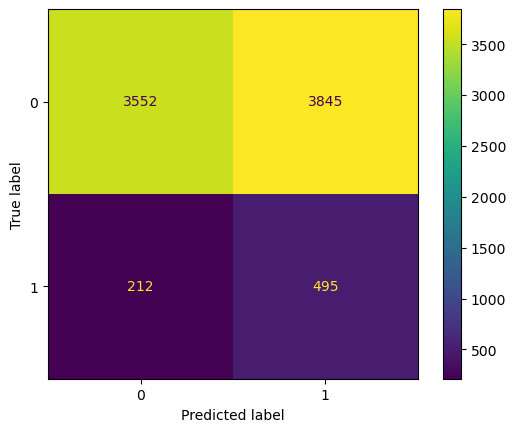

In [88]:
modelo = DecisionTreeClassifier(max_depth=10)
modelo.fit(x_balanceada, y_balanceada)
y_previsto = modelo.predict(X_test)

print(classification_report(y_test, y_previsto))
ConfusionMatrixDisplay.from_predictions(y_test, y_previsto)

**Análisis Final:**
Al observar esta última matriz de confusión y el reporte de clasificación, notaremos que logramos nuestro objetivo de aumentar el *Recall* para la clase 1 (Morosos). 

Es cierto, hemos aumentado la cantidad de Falsos Positivos (rechazamos a personas que sí iban a pagar), lo cual afecta la *Precision*, pero en términos de riesgo, para el banco es mucho más preferible esta postura conservadora que permite identificar de forma más agresiva a los posibles deudores problemáticos.